# Naive Bayes Model on cleaned_combined.csv

This notebook builds a Gaussian Naive Bayes classifier for load-state prediction (Idle / Active / Stressed) using `data/cleaned_combined.csv`.

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

DATA_PATH = "data/cleaned_combined.csv"
TEST_SIZE = 0.25
RANDOM_SEED = 42

## 1) Load Data

In [7]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nDtypes:")
print(df.dtypes.value_counts())

display(df.head(3))

Shape: 29,146 rows x 73 columns

Dtypes:
int64      36
float64    34
object      3
Name: count, dtype: int64


,timestamp,Processor_DPC Rate,Processor_% Idle Time,Processor_% Interrupt Time,Processor_% User Time,Processor_% C1 Time,Processor_% Processor Time,Processor_C1 Transitions/sec,Processor_% DPC Time,Processor_% Privileged Time,Processor_DPCs Queued/sec,Processor_Interrupts/sec,Process_Pool Paged Bytes,Process_IO Read Operations/sec,Process_Working Set - Private,Process_Working Set Peak,Process_IO Write Operations/sec,Process_Page File Bytes,Process_% User Time,Process_Virtual Bytes Peak,Process_Page File Bytes Peak,Process_IO Other Bytes/sec,Process_Private Bytes,Process_IO Write Bytes/sec,Process_Virtual Bytes,Process_% Processor Time,Process_Pool Nonpaged Bytes,Process_Working Set,Process_Page Faults/sec,Process_IO Other Operations/sec,Process_IO Data Operations/sec,Process_Thread Count,Process_% Privileged Time,Process_IO Data Bytes/sec,Process_IO Read Bytes/sec,Process_Handle Count,Memory_Pool Paged Bytes,Memory_Free & Zero Page List Bytes,Memory_Cache Bytes Peak,Memory_System Code Resident Bytes,Memory_Available Bytes,Memory_Commit Limit,Memory_Transition Pages RePurposed/sec,Memory_Pages Output/sec,Memory_Page Reads/sec,Memory_Demand Zero Faults/sec,Memory_Available KBytes,Memory_Pages/sec,Memory_Cache Bytes,Memory_Pool Nonpaged Bytes,Memory_Page Faults/sec,Memory_Transition Faults/sec,Memory_System Cache Resident Bytes,Memory_Standby Cache Reserve Bytes,Memory_Page Writes/sec,Memory_System Code Total Bytes,Memory_Standby Cache Core Bytes,Memory_System Driver Resident Bytes,Memory_Standby Cache Normal Priority Bytes,Memory_Pool Paged Allocs,Memory_Pool Nonpaged Allocs,Memory_% Committed Bytes In Use,Memory_Free System Page Table Entries,Memory_Available MBytes,Memory_Modified Page List Bytes,Memory_Cache Faults/sec,Memory_Committed Bytes,Memory_System Driver Total Bytes,Memory_Pages Input/sec,Memory_Pool Paged Resident Bytes,Memory_Write Copies/sec,os,source_file
0,2019-04-01 23:12:31.353,14,74.791667,0.000000,12.324669,73.333333,24.103018,360.486597,0.078128,4.303456,90.931343,1200.657980,5947120,2.203341,273567744,1015803904,1.302016,588537856,23.124375,4703268864,783409152,4377.870224,588537856,5699.781892,3962359808,196.093542,861456,631066624,1526.226663,93.866739,3.800078,549,137.130750,6315.387409,246.001879,13404,86798336,21934080,28532736,1798144,434634752,2146951168,0.000000,3.902694,10.516329,730.220165,424448,180.999629,18300928,50925568,1813.000397,561.740664,18300928,330629120,0.099996,7155712,16150528,3555328,65921024,65935,53841,42.636762,33557798,414,33116160,0.600018,915390464,5849088,67.310683,42708992,0.0,win7,win7_normal_1.csv
1,2019-04-01 23:12:46.353,0,90.208333,0.208333,2.083333,88.009289,9.791667,216.615181,0.208333,7.708333,278.457581,337.965047,5953864,13.676043,274554880,1015984128,1.467673,593522688,2.083333,4703268864,783552512,12445.265974,593522688,17621.414810,3968475136,99.583333,863120,632049664,465.519166,1026.703922,15.143716,554,97.500000,45077.572451,27456.157641,13414,91947008,1118208,28532736,1789952,435105792,2146951168,1219.903048,171.851157,246.168777,411.081843,424908,2129.526699,18055168,51367936,707.018074,242.299457,18055168,275800064,0.733836,7155712,42127360,3543040,116060160,72996,57084,43.146341,33557825,414,26374144,31.955242,926330880,5849088,1957.675542,48304128,0.0,win7,win7_normal_1.csv
2,2019-04-01 23:13:01.353,0,99.791667,0.000000,0.104167,98.920487,0.208333,67.861457,0.000000,0.104167,5.666232,71.994473,5954184,11.265802,271343616,1016094720,3.866370,592531456,0.104167,4703268864,783708160,3036.766857,592531456,10899.029912,3963748352,100.000000,860632,628658176,39.996929,89.126491,15.132172,547,99.895833,11346.595551,447.565639,13390,91955200,1867776,28532736,1785856,438833152,2146951168,0.000000,23.664850,0.133323,42.396745,428548,23.798173,17784832,51380224,49.262885,5.599570,17784832,278405120,0.133323,7155712,42143744,3518464,116416512,72911,57024,43.074798,33557823,418,27045888,1.199908,924794880,5849088,0.133323,48107520,0.0,win7,win7_normal_1.csv


## 2) Build Rule-Based Target (load_state)

In [8]:
CPU_COL = "Processor_% Processor Time"
MEM_COL = "Memory_Pages/sec"
IO_COL = "Process_IO Data Bytes/sec"
IDLE_COL = "Processor_% Idle Time"

def assign_load_state(frame: pd.DataFrame) -> pd.Series:
    cpu = frame[CPU_COL].fillna(0)
    mem = frame[MEM_COL].fillna(0)
    io = frame[IO_COL].fillna(0)

    state = pd.Series("Active", index=frame.index)
    state[cpu >= 30] = "Stressed"
    state[(mem > 200) & (io > 1e6)] = "Stressed"
    state[(cpu < 5) & (io < 5e4)] = "Idle"
    return state

df["load_state"] = assign_load_state(df)
print(df["load_state"].value_counts().to_string())

load_state
Active      16564
Stressed     8438
Idle         4144


## 3) Leakage-Safe Feature Matrix

In [9]:
LABEL_COLS = {
    CPU_COL,
    MEM_COL,
    IO_COL,
    IDLE_COL,
}

LEAKY_COLS = {
    "Processor_% User Time",
    "Processor_% Privileged Time",
    "Processor_% DPC Time",
    "Processor_% Interrupt Time",
    "Processor_% C1 Time",
}

META_COLS = {"timestamp", "source_file", "os", "load_state"}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in numeric_cols
    if c not in LABEL_COLS and c not in LEAKY_COLS and c not in META_COLS
]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["load_state"]

print(f"Features used: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts().to_string()}")

Features used: 61
X shape: (29146, 61)
y distribution:
load_state
Active      16564
Stressed     8438
Idle         4144


## 4) Train Gaussian Naive Bayes and Evaluate

GAUSSIAN NAIVE BAYES - EVALUATION
              precision    recall  f1-score   support

      Active     0.8225    0.4644    0.5936      4141
        Idle     0.3230    0.9479    0.4818      1036
    Stressed     0.6265    0.5668    0.5952      2110

    accuracy                         0.5628      7287
   macro avg     0.5907    0.6597    0.5569      7287
weighted avg     0.6947    0.5628    0.5782      7287

Accuracy           : 0.5628
Weighted Precision : 0.6947
Weighted Recall    : 0.5628
Weighted F1-score  : 0.5782


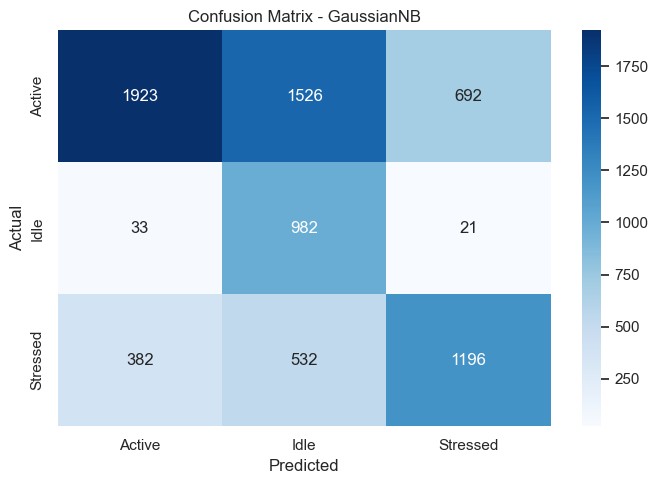


Top 10 uncertain predictions:


,true_label,pred_label,max_prob,uncertainty
0,Active,Stressed,0.501206,0.498794
1,Stressed,Active,0.503714,0.496286
2,Stressed,Active,0.503793,0.496207
3,Active,Stressed,0.506999,0.493001
4,Stressed,Active,0.507984,0.492016
5,Stressed,Stressed,0.508505,0.491495
6,Stressed,Stressed,0.510963,0.489037
7,Active,Active,0.511881,0.488119
8,Stressed,Stressed,0.522513,0.477487
9,Stressed,Active,0.527319,0.472681


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=" * 55)
print("GAUSSIAN NAIVE BAYES - EVALUATION")
print("=" * 55)
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
print(f"Accuracy           : {acc:.4f}")
print(f"Weighted Precision : {prec:.4f}")
print(f"Weighted Recall    : {rec:.4f}")
print(f"Weighted F1-score  : {f1:.4f}")

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - GaussianNB")
plt.tight_layout()
plt.show()

max_prob = y_prob.max(axis=1)
uncertain_idx = np.argsort(max_prob)[:10]

uncertain_df = pd.DataFrame({
    "true_label": y_test.iloc[uncertain_idx].values,
    "pred_label": y_pred[uncertain_idx],
    "max_prob": max_prob[uncertain_idx],
    "uncertainty": 1 - max_prob[uncertain_idx],
})

print("\nTop 10 uncertain predictions:")
display(uncertain_df.sort_values("max_prob"))

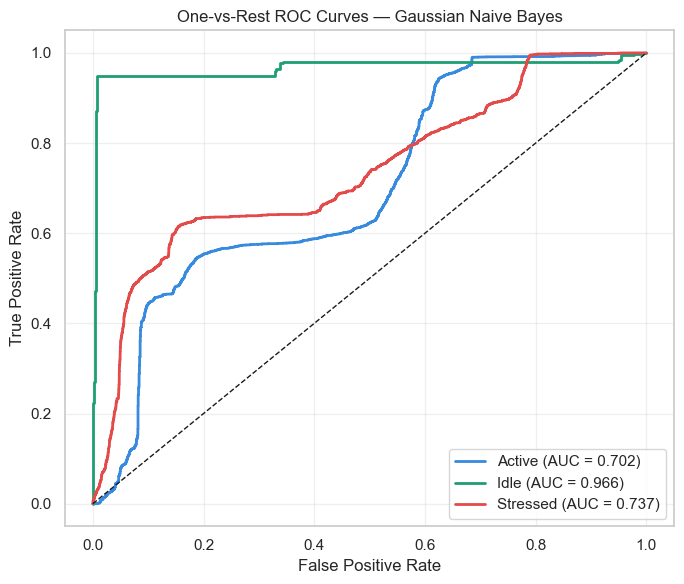

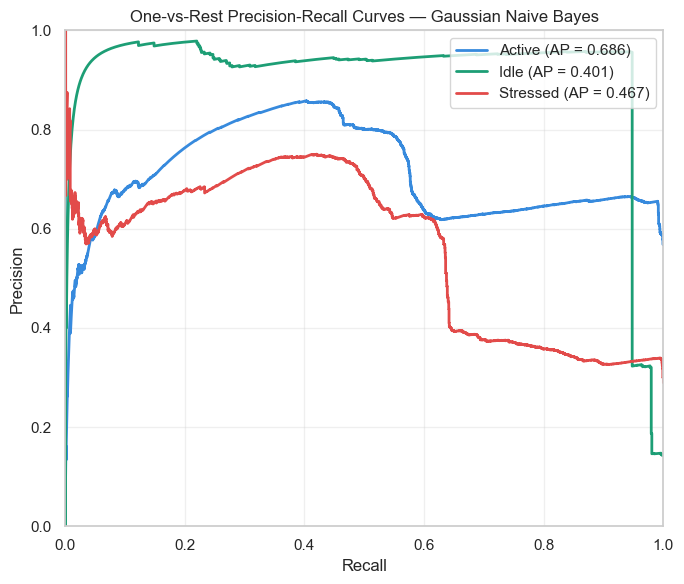

In [11]:
# Plot ROC curves for each class (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=sorted(y.unique()))
classes_ordered = sorted(y.unique())
colors = ["#378ADD", "#1D9E75", "#E24B4A"]

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(classes_ordered, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", linewidth=1)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("One-vs-Rest ROC Curves — Gaussian Naive Bayes")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curves for each class
fig_pr, ax_pr = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(classes_ordered, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    avg_precision = np.mean(precision[:-1])  # Average precision (simplified)
    ax_pr.plot(recall, precision, color=color, linewidth=2, label=f"{cls} (AP = {avg_precision:.3f})")

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("One-vs-Rest Precision-Recall Curves — Gaussian Naive Bayes")
ax_pr.legend(loc="upper right")
ax_pr.grid(alpha=0.3)
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1])
plt.tight_layout()
plt.show()

## 5) ROC and Precision-Recall Curves